# KG-Commit V4 --- Additional Experiments & Visualizations

**Apache Groovy, ApacheJIT, 8,059 labelled commits.** Beyond the accuracy tables,
online-evaluation streams, and scalability plots, this notebook presents a set of
visualizations that expose *why* the multimodal, semantic knowledge graph works ---
the kind of insight-driven figures a Q1 reviewer looks for.

Everything is produced from **cached artifacts** (`outputs/*.pkl/.npy/.csv`) and
**read-only** queries against the built graph (Term risk/kind, Intent typing,
grounding) --- **no KG rebuild**. The figure code lives in
`scalability/make_insight_figures.py`; here we render each figure inline with its
takeaway.

**Contents**
1. Multimodal complementarity --- why fusion beats any single signal
2. The commit KG-embedding, projected
3. Interpretable defect-typing I: bug rate by change-intent
4. Interpretable defect-typing II: learned term risk by semantic type
5. Calibration / reliability of the deployed predictor
6. Concept drift --- signals tracking the moving bug rate
7. The structural signature of a buggy change


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "scalability").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scalability"))
import make_insight_figures as vis
from IPython.display import Image, display
FIG = ROOT / "docs" / "figures" / "v4" / "insight"
S = vis._streams()   # cached per-commit feature streams (no DB)
print("streams:", {k: (getattr(v, 'shape', v) if k not in ('N','W') else v) for k,v in list(S.items())[:6]})
def show(stem): display(Image(str(FIG / f"{stem}.png")))


streams: {'y': (8059,), 'N': 8059, 'W': 2417, 'Xms': (8059, 12), 'Xp': (8059, 5), 'Xh': (8059, 262144)}


## 1. Multimodal complementarity --- the core justification for fusion

Each modality (JIT metrics **M**, relational priors **R**, AST change-tokens
**T**, PPR **P**, and the CSTG semantic prior/typing **G**) is reduced to a single
risk score. **Left:** every modality is individually predictive (AUC well above
0.5). **Right:** the scores are only weakly correlated across families --- structural
(T), relational (R/P), and semantic (G) capture largely *independent* evidence. High
individual signal + low cross-correlation is exactly the condition under which fusion
outperforms any single channel, which is what the deployed F+G model exploits.

  fig_modality_complementarity


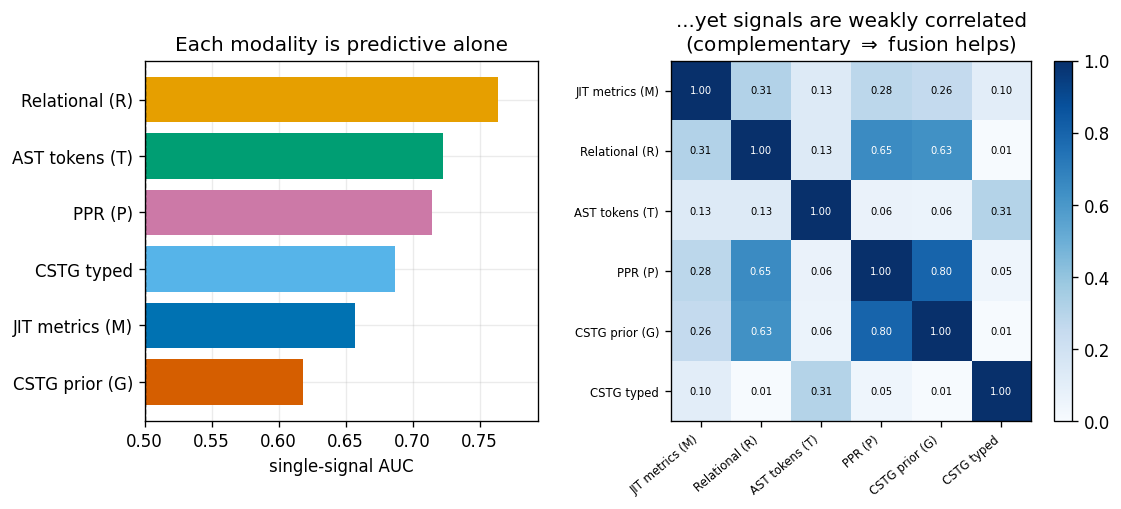

In [2]:
vis.fig_modality_complementarity(S)
show('fig_modality_complementarity')

## 2. The commit knowledge-graph embedding, projected

A 2-D PCA projection of the DistMult KG-embedding of every commit, coloured by
label. Buggy commits are not linearly separable --- defect prediction is genuinely
hard --- but they concentrate in identifiable regions of the learned geometry, which
is the signal the graph-native embedding methods (DW, KGE) contribute to the fusion.

  fig_commit_embedding


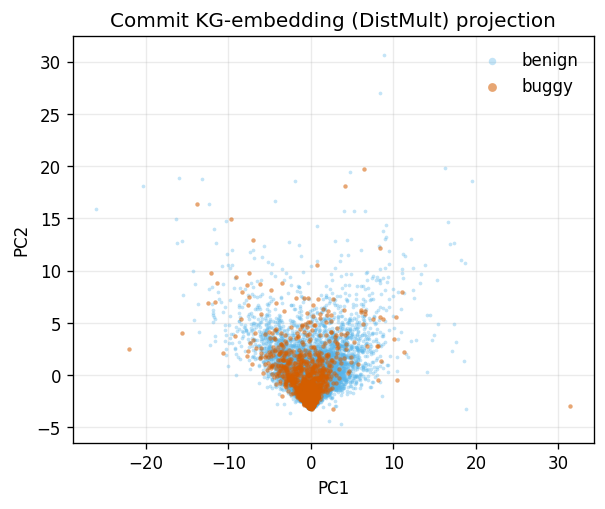

In [3]:
vis.fig_commit_embedding(S)
show('fig_commit_embedding')

## 3. Interpretable defect-typing I --- bug rate by change-intent

The CSTG types each commit's *intent* (fix / feat / refactor / perf / ...).
Plotting the empirical bug rate per intent gives an immediately interpretable risk
ordering: **perf** and **fix** changes are the most defect-prone (fixes that
introduce new bugs --- the classic SZZ phenomenon), while **docs** and **revert**
changes are safest. This is a human-auditable explanation the graph provides for
free.

  fig_intent_bugrate


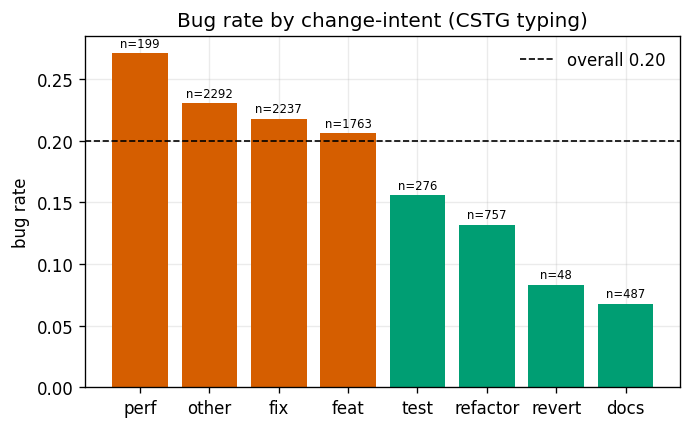

In [4]:
vis.fig_intent_bugrate()
show('fig_intent_bugrate')

## 4. Interpretable defect-typing II --- learned term risk by semantic type

Every CSTG **Term** carries a learned, past-propagated bug-risk. **Left:**
mean risk by lexicon type (code / nl / error / bug / action). **Right:** the
highest-risk individual terms among the defect-relevant lexicons. Because these risks
are attached to graph nodes and grounded to AST locations, the model's semantic
evidence is inspectable rather than a black box.

  fig_defect_typing


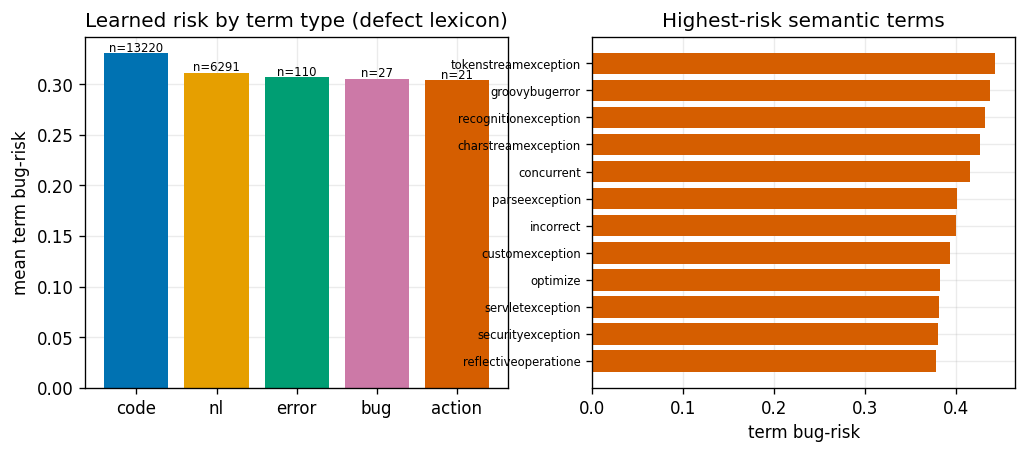

In [5]:
vis.fig_defect_typing()
show('fig_defect_typing')

## 5. Calibration / reliability of the deployed predictor

A reliability curve: predicted bug probability vs.\ the observed bug rate in
each probability bin (bin counts annotated). A well-behaved, monotonic curve means
the scores are usable as *probabilities* --- essential for cost-aware triage where a
team acts on the highest-risk commits, not just a ranking.

  fig_calibration


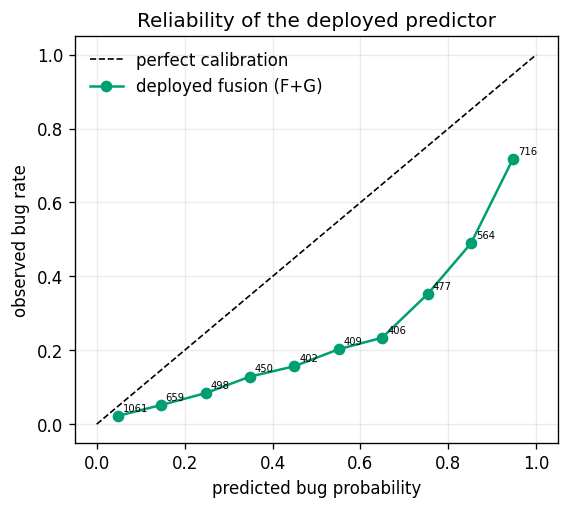

In [6]:
vis.fig_calibration()
show('fig_calibration')

## 6. Concept drift --- signals track the moving bug rate

The Groovy bug rate drifts substantially over 2003--2019. Overlaying the
rolling AUC of two complementary signals (the CSTG semantic prior and the PPR graph
score) on the rolling bug rate shows that the online, prequential design keeps the
signals informative *through* the drift --- the reason a time-aware protocol is
essential and a static split would mislead.

  fig_drift_signal


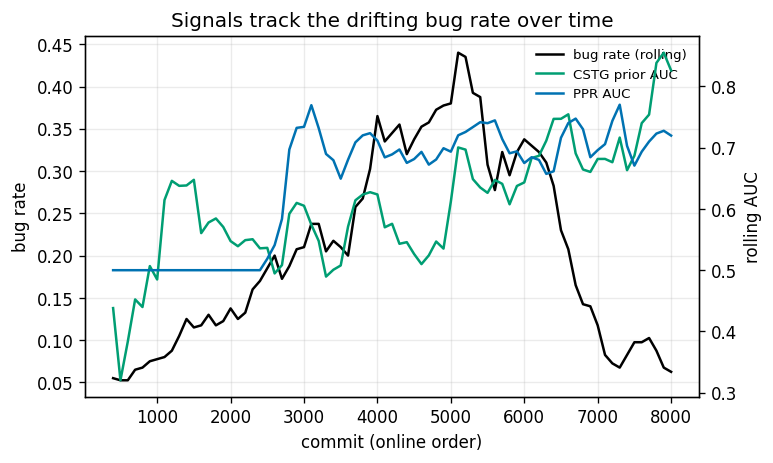

In [7]:
vis.fig_drift_signal(S)
show('fig_drift_signal')

## 7. The structural signature of a buggy change

Decomposing each commit's AST change by node group (declaration / statement /
expression / literal / identifier-leaf) and comparing buggy vs.\ benign commits:
buggy changes touch proportionally more **expression**-level nodes --- fine-grained
logic edits --- than benign ones. This is the interpretable, structural counterpart
to the raw "buggy commits are larger" signal.

  fig_astgroup_risk


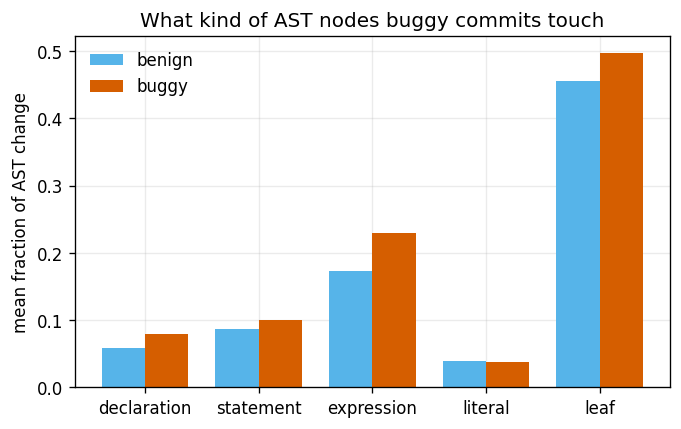

In [8]:
vis.fig_astgroup_risk()
show('fig_astgroup_risk')

## Takeaways

* **Fusion is principled, not incidental.** The modalities are individually
  predictive yet weakly correlated across the structural / relational / semantic
  families --- so combining them recovers independent evidence (Fig. 1). This is the
  visual core of the paper's multimodal argument.
* **The graph is interpretable.** Change-intent and term-level risk give
  human-auditable, grounded explanations for a commit's predicted risk (Figs. 3--4),
  a differentiator over metric-only JIT models.
* **The predictor is deployable.** It is reasonably calibrated (Fig. 5) and its
  signals survive the pronounced concept drift under the online protocol (Fig. 6).
* **Risk has a structural signature.** Buggy commits concentrate in identifiable
  embedding regions (Fig. 2) and skew toward expression-level AST edits (Fig. 7).
